# ARIMA BEST & Random Forest

## 1. Imports

In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from hydrosense.database.bigquery import load_plean
from hydrosense.ml_logic.model import initialize_model, optimize_model, train_model, evaluate_model, predict_model
from hydrosense.ml_logic.folding import get_folds
from hydrosense.preprocess.preprocessor import preprocess_week, scale_feats, prepare_lags, split_data, split_lagged_data
from hydrosense.interface.main import  train


from hydrosense import params

DATA_CODE_PIEZO = "BSS001QHYH"
DATA_CODE_PIEZO = params.TARGETS_BSS[9]

TARGET_COL   = "niveau_nappe_eau"
DATE_COL     = "date_mesure"
FEATURE_COLS = ["semaine_sin", "semaine_cos", "PU_synth", "PC1", "PC2", "PC3"]


TRAIN_END = "2025-02-28"
TEST_START = "2025-03-01"
TEST_END = "2025-05-31"


## 2. Chargement des données
Lecture du fichier BQ

### Mise en forme de l'index
Conversion de la colonne `date_mesure` en index temporel de type `DatetimeIndex`.

> **Pourquoi ?** Les méthodes de séries temporelles comme `resample()` nécessitent
> un index de type `DatetimeIndex`. En définissant la date comme index, on peut
> ensuite rééchantillonner, découper et aligner les données par date facilement.



**Pris en charge par function la fonction** `load_data`

In [6]:
df = load_plean(DATA_CODE_PIEZO)
df_w = preprocess_week(df)
df_w

✅ BSS001SHNE : 8888 lignes de features ML chargées.

⭐️ Use case: preprocess
✅ Moyenne hebdomadaire — 898 semaines | 10 colonnes



,niveau_nappe_eau,RR_synth,PU_synth,TM_synth,PC1,PC2,PC3,FFM_synth,semaine_sin,semaine_cos
date_mesure,,,,,,,,,,
2009-03-22,6.115714,0.00,-20.218,11.014286,0.430319,0.478722,-0.119501,5.057143,0.992709,0.120537
2009-03-29,5.541429,4.58,-14.007,9.060000,0.419981,0.467221,-0.116630,4.457143,1.0,-0.0
2009-04-05,5.285714,0.79,-18.434,10.341429,0.381053,0.423914,-0.105820,3.628571,0.992709,-0.120537
2009-04-12,5.175714,20.34,-1.460,11.458571,0.321687,0.357870,-0.089333,4.271429,0.970942,-0.239316
2009-04-19,5.084286,19.45,-0.207,10.982857,0.283731,0.315646,-0.078793,2.414286,0.935016,-0.354605
...,...,...,...,...,...,...,...,...,...,...
2026-05-03,7.652857,17.96,-7.664,16.718571,1.610709,1.791885,-0.447300,2.400000,0.822984,-0.568065
2026-05-10,7.375714,15.53,-10.502,15.477143,1.464240,1.628941,-0.406625,2.757143,0.748511,-0.663123
2026-05-17,7.160000,29.31,3.824,12.674286,1.316312,1.464373,-0.365544,3.814286,0.663123,-0.748511


(np.float64(18611.0), np.float64(19341.0))

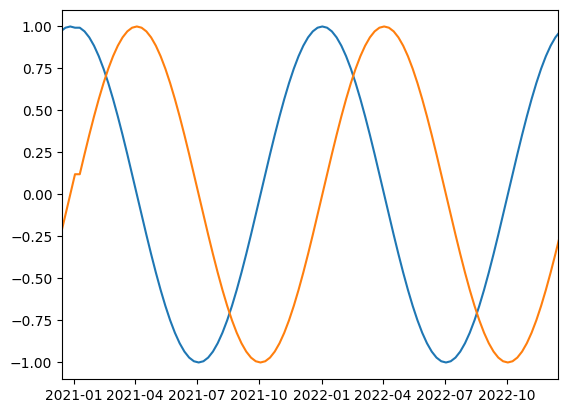

In [7]:
import matplotlib.pyplot as plt
from datetime import datetime

# plt.plot(df_w.index.isocalendar().week)
plt.plot(df_w[['semaine_cos','semaine_sin']])

date_debut = datetime(2020, 12, 15)
date_fin = datetime(2022, 12, 15)

plt.xlim(date_debut, date_fin)

### Pipeline

### Lagging

Le modèle ne voit jamais ces données pendant l'entraînement — c'est ce qui garantit une évaluation honnête.

In [8]:
# On cree le lag en premier.
X_lagged = prepare_lags(df_w)

# On split ensuite.
print(X_lagged.columns)
X_train, X_test= split_lagged_data(X_lagged, FEATURE_COLS, TARGET_COL, TRAIN_END, TEST_START, TEST_END)
# On a perdu le y )
_, _, y_train, y_test = split_data(df_w, FEATURE_COLS, TARGET_COL, TRAIN_END, TEST_START, TEST_END)

# il faut clipper les données y_train
y_train = y_train.loc[X_train.index]


Index(['RR_synth', 'TM_synth', 'FFM_synth', 'semaine_sin', 'semaine_cos',
       'niveau_nappe_eau_lag_1', 'niveau_nappe_eau_lag_2',
       'niveau_nappe_eau_lag_3', 'niveau_nappe_eau_lag_4',
       'niveau_nappe_eau_lag_52', 'PC1_lag_1', 'PC2_lag_1', 'PC3_lag_1',
       'PU_synth_lag_1', 'PU_synth_lag_2', 'PU_synth_lag_3', 'PU_synth_lag_4'],
      dtype='object')

⭐️ Use case: split_data
✅ split_data() done — Train : 832 | Test : 13



In [9]:
# Refaire le scale avec les
X_train_scaled, X_test_scaled, scaler, _ = scale_feats(X_train_df = X_train, X_test_df= X_test)

Adimensionnement des features (Standardisation)...
✅ Adimensionnement terminé : 12 en Standard, 0 en MinMax.


### Sizes


In [10]:
assert X_train_scaled.shape[0] == y_train.shape[0]
pd.concat([X_train_scaled, X_test_scaled]).tail(15)

,semaine_sin,semaine_cos,niveau_nappe_eau_lag_1,niveau_nappe_eau_lag_2,niveau_nappe_eau_lag_3,niveau_nappe_eau_lag_4,niveau_nappe_eau_lag_52,PC1_lag_1,PC2_lag_1,PC3_lag_1,PU_synth_lag_1,PU_synth_lag_2,PU_synth_lag_3,PU_synth_lag_4
date_mesure,,,,,,,,,,,,,,
2025-02-16,0.748511,0.663123,1.461513,1.513456,1.155076,1.331572,2.253643,1.548225,-0.352884,-0.770849,0.790256,1.704008,0.617671,-0.022003
2025-02-23,0.822984,0.568065,1.505309,1.464640,1.516222,1.157426,2.238354,1.488263,-0.076939,-0.515890,0.377805,0.790985,1.704814,0.620955
2025-03-02,0.885456,0.464723,1.458208,1.508492,1.467351,1.518986,2.629067,1.459796,0.139338,-0.229988,0.355710,0.378501,0.791565,1.710130
2025-03-09,0.935016,0.354605,1.379706,1.461331,1.511252,1.470060,2.790448,1.368825,0.345119,-0.126556,0.364284,0.356404,0.378979,0.795174
2025-03-16,0.970942,0.239316,1.296247,1.382729,1.464038,1.514011,2.561966,1.336406,0.447963,-0.117195,-0.464717,0.364979,0.356877,0.381817
2025-03-23,0.992709,0.120537,1.178082,1.299163,1.385348,1.466743,2.277425,1.261120,0.551785,-0.245606,0.108287,-0.464088,0.365454,0.359674
2025-03-30,1.0,-0.0,1.026863,1.180846,1.301688,1.387962,2.156814,1.204582,0.615677,-0.235222,-0.188556,0.108961,-0.463817,0.368267
2025-04-06,0.992709,-0.120537,0.916961,1.029434,1.183239,1.304206,2.199283,1.133694,0.663676,-0.261963,-0.458922,-0.187905,0.109373,-0.462555
2025-04-13,0.970942,-0.239316,0.835980,0.919392,1.031657,1.185621,1.955512,1.083831,0.643572,-0.267039,-0.622490,-0.458292,-0.187566,0.111707


### Training the model 

In [11]:
base_model, _ = train(X_train_scaled, y_train, pick_model= 'BASE')
evaluate_model(base_model, X_train_scaled, y_train)
evaluate_model(base_model, X_test_scaled, y_test)
y_pred = base_model.predict(X_test=X_test_scaled)

⏳ Initialisation de la persistance annuelle (J-365)...
✅ train() done — Baseline prête.

Evaluating model on 780 rows...
✅ Model evaluated on set (train, val ou test)
   MAE  : 1.3838  (erreur moyenne en mètres NGF)
   RMSE : 1.8451 (pénalise les grandes erreurs)
   R²   : -0.1363  (1.0 = parfait)
   Max Error: 9.1971 (erreur maximale absolue)
   RMSSE: nan (erreur par rapport au choix naif)

Evaluating model on 13 rows...
✅ Model evaluated on set (train, val ou test)
   MAE  : 2.0626  (erreur moyenne en mètres NGF)
   RMSE : 2.0818 (pénalise les grandes erreurs)
   R²   : -3.0641  (1.0 = parfait)
   Max Error: 0 (erreur maximale absolue)
   RMSSE: nan (erreur par rapport au choix naif)


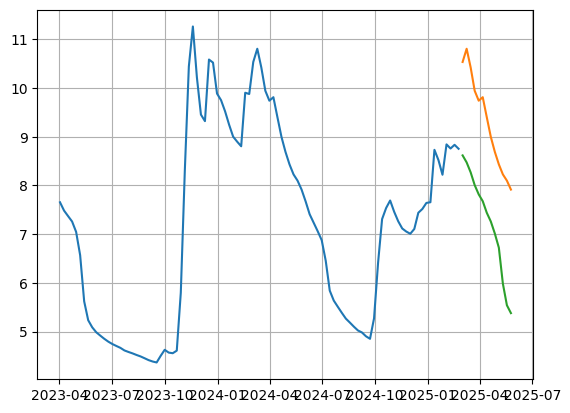

In [12]:
import matplotlib.pyplot as plt

plt.plot(y_train.iloc[-100:])
plt.plot(X_test_scaled.index, y_pred)
plt.plot(y_test)
plt.grid(True)

In [13]:
from hydrosense.interface.main import train

# --- 4. ÉVALUATION SUR LE TEST SET (Mars → Mai 2025) ---
lasso, history = train(X_train_scaled, y_train, pick_model= 'LASSO')
metrics_train = evaluate_model(lasso, X_train_scaled, y_train)
metrics_lasso = evaluate_model(lasso, X_test_scaled, y_test)

# ---
xbg, history = train(X_train_scaled, y_train, pick_model= 'XGB')
metrics_train = evaluate_model(xbg, X_train_scaled, y_train)
metrics_xgb = evaluate_model(xbg, X_test_scaled, y_test)


# --- 5. VISUALISATION DES COEFFICIENTS (Bonus Métier) ---
# Pour un modèle linéaire (Lasso), regarder les poids des variables est magique
if hasattr(lasso, 'coef_'):
    print(f"\n🧠 Poids des variables calculés par le Lasso : alpha {lasso.alpha}")

    for col, coef in zip(X_train_scaled.columns, lasso.coef_):
        print(f" ── {col:<18} : {coef:+.4f}")



Use case: train (Mode Baseline Lasso)
✅ train() done — Modèle Lasso entraîné.


Evaluating model on 780 rows...
✅ Model evaluated on set (train, val ou test)
   MAE  : 0.2553  (erreur moyenne en mètres NGF)
   RMSE : 0.4599 (pénalise les grandes erreurs)
   R²   : 0.9294  (1.0 = parfait)
   Max Error: 6.8571 (erreur maximale absolue)
   RMSSE: nan (erreur par rapport au choix naif)

Evaluating model on 13 rows...
✅ Model evaluated on set (train, val ou test)
   MAE  : 0.2052  (erreur moyenne en mètres NGF)
   RMSE : 0.2831 (pénalise les grandes erreurs)
   R²   : 0.9248  (1.0 = parfait)
   Max Error: 0.1475 (erreur maximale absolue)
   RMSSE: nan (erreur par rapport au choix naif)

Use case: train

⭐️ Use case: train (Mode XGB)
Model initialized

Training model...
✅ Model trained on 780 rows in 2.15s
   Train MAE  : 0.0859
   Train RMSE : 0.1246
✅ train() done 


Evaluating model on 780 rows...
✅ Model evaluated on set (train, val ou test)
   MAE  : 0.0859  (erreur moyenne en mètres N

### 3. Timing and diagnostic de tout les piezos

Chronomètre.

Stats 

Lag avec la pluie efficace.


In [14]:
d0 = load_plean(params.TARGETS_BSS[0])
d0

✅ BSS002DEZW : 10370 lignes de features ML chargées.


,bss_id,date_mesure,niveau_nappe_eau,RR_synth,TM_synth,FFM_synth,PU_synth,PC1,PC2,PC3
0,BSS002DEZW,1998-01-08,91.07,0.0,7.00,1.00,-0.666,NaN,NaN,NaN
1,BSS002DEZW,1998-01-09,91.07,0.0,7.00,1.60,-0.918,NaN,NaN,NaN
2,BSS002DEZW,1998-01-10,91.09,0.0,7.70,2.30,-1.202,NaN,NaN,NaN
3,BSS002DEZW,1998-01-11,91.12,0.0,13.30,6.00,-2.661,NaN,NaN,NaN
4,BSS002DEZW,1998-01-12,91.13,0.0,13.70,6.90,-2.906,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
10365,BSS002DEZW,2026-05-26,91.26,0.0,26.41,2.55,-5.345,1.367174,NaN,NaN
10366,BSS002DEZW,2026-05-27,91.25,0.0,26.49,1.18,-4.649,1.358176,NaN,NaN
10367,BSS002DEZW,2026-05-28,91.24,0.0,27.27,1.85,-5.121,1.343778,NaN,NaN
10368,BSS002DEZW,2026-05-29,91.23,0.0,26.26,1.64,-4.899,1.323980,NaN,NaN


In [ ]:
from hydrosense.preprocess.preprocessor import make_preproc_week
from hydrosense.utils.evap import lag_pluie

lags = []
corr_list = []
metrics = {}


for bss in params.TARGETS_BSS[:]:
    df = load_plean(bss)
    lag, cor, _ = lag_pluie(df)
    lags.append(lag)
    corr_list.append(cor)

    Xt, Xe, yt, ye , _ = make_preproc_week(df, FEATURE_COLS, TARGET_COL, TRAIN_END, TEST_START, TEST_END)
    m, _  = train(Xt, yt, pick_model= 'LASSO')
    metrics['bss'] = evaluate_model(m, Xe, ye)


✅ BSS002DEZW : 10370 lignes de features ML chargées.
✅ Le temps de réponse optimal estimé de la nappe est de 99 jours (Corrélation: 0.207).

⭐️ Use case: preprocess
✅ Moyenne hebdomadaire — 1482 semaines | 10 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 1416 | Test : 13

Adimensionnement des features (Standardisation)...
✅ Adimensionnement terminé : 12 en Standard, 0 en MinMax.

Use case: train (Mode Baseline Lasso)
✅ train() done — Modèle Lasso entraîné.


Evaluating model on 13 rows...
✅ Model evaluated on set (train, val ou test)
   MAE  : 0.1387  (erreur moyenne en mètres NGF)
   RMSE : 0.4407 (pénalise les grandes erreurs)
   R²   : -0.2336  (1.0 = parfait)
   Max Error: 1.5875 (erreur maximale absolue)
   RMSSE: nan (erreur par rapport au choix naif)
✅ BSS000ZPHJ : 7464 lignes de features ML chargées.
✅ Le temps de réponse optimal estimé de la nappe est de 93 jours (Corrélation: 0.285).

⭐️ Use case: preprocess
✅ Moyenne hebdomadaire — 1067 semaines | 10 colon

In [ ]:
lags


NameError: name 'TARGETS_BSS' is not defined

✅ BSS002DEZW : 10370 lignes de features ML chargées.
✅ Le temps de réponse optimal estimé de la nappe est de 99 jours (Corrélation: 0.207).
✅ BSS001QHYH : 11821 lignes de features ML chargées.
✅ Le temps de réponse optimal estimé de la nappe est de 10 jours (Corrélation: 0.325).


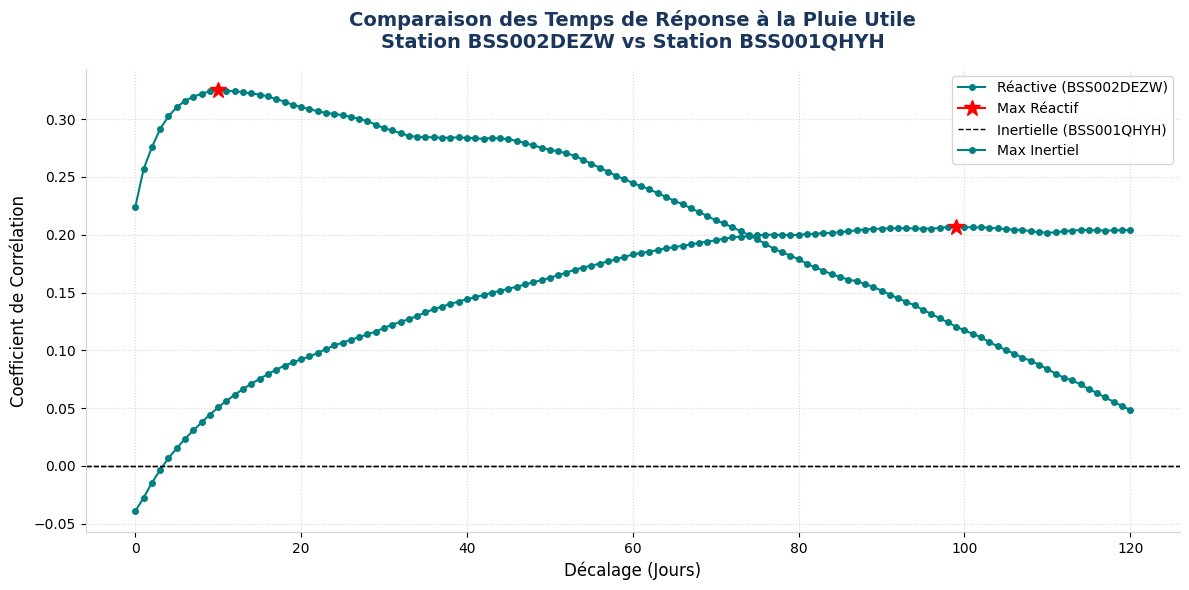

In [24]:
fig, ax = plt.subplots(figsize=(12, 6))

df_0 = load_plean(params.TARGETS_BSS[0])
_ , _ , ax = lag_pluie(df_0, toggle_plot= True, ax = ax)

df_1 = load_plean(params.TARGETS_BSS[6])
_, _ , ax =        lag_pluie(df_1, toggle_plot= True, ax = ax )


# 4. On personnalise la figure finale combinée
ax.set_title(f"Comparaison des Temps de Réponse à la Pluie Utile\nStation {params.TARGETS_BSS[0]} vs Station {params.TARGETS_BSS[6]}",
             fontsize=14, fontweight='bold', color='#1a365d', pad=15)

# On rafraîchit la légende pour inclure proprement les deux stations
ax.legend([
    f"Réactive ({params.TARGETS_BSS[0]})", "Max Réactif",
    f"Inertielle ({params.TARGETS_BSS[6]})", "Max Inertiel"
], loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

In [ ]:
### SPLITS

from hydrosense.ml_logic.folding import get_folds

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ==========================================
# TRAIN / VAL Folding

splits = get_folds(y_mensuel.index, n_splits=10, min_train_years=3 , val_months_duration= 3)

TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'RangeIndex'

## 4. XGBoost — Feature Engineering

Le **Random Forest** n'est pas un modèle de séries temporelles natif : il ne comprend pas
la notion de temps. On lui fournit donc des **features de lag** (décalages temporels) :

| Feature | Signification |
|---|---|
| `lag_1` | Niveau du mois précédent |
| `lag_2` | Niveau il y a 2 mois |
| `lag_3` | Niveau il y a 3 mois |
| `lag_12` | Niveau il y a 12 mois (même saison l'an dernier) |
| `mois` | Numéro du mois (saisonnalité) |
| `moyenne_3m` | Tendance récente sur 3 mois |
| `moyenne_6m` | Tendance moyen terme sur 6 mois |

On transforme ainsi un problème temporel en problème de **régression supervisée classique**.

### 4.1 Data lagging mensuel + Folding 

In [ ]:
from hydrosense.interface.main import load_data, evaluate, evaluate_deeper, preprocess, train
from hydrosense.ml_logic.folding import get_folds
from hydrosense.preprocess.cleaning import clean_piezo
from hydrosense.database.bigquery import load_piezo_bq
from hydrosense import params


DATA_CODE_PIEZO = "BSS001QHYH"
df = clean_piezo(load_piezo_bq(DATA_CODE_PIEZO))


if params.DATE_COL in df.columns:
    df[params.DATE_COL] = pd.to_datetime(df[params.DATE_COL])
    df.set_index(params.DATE_COL, inplace=True)
df = df.sort_index()

df_ml = preprocess(df)
X_train_df, X_test_df, y_train_df, y_test_df = split_data(df_ml)

# TRAIN / VAL Folding
splits_ml = get_folds(X_train_df.index, n_splits=25, min_train_years=3 , val_months_duration= 3)

# 2. Train — optimize=True pour GridSearchCV
model, history = train(X_train_df, y_train_df, optimize=False)

# 3. Evaluate — même modèle, pas de rechargement
metrics = evaluate(model, X_test_df, y_test_df)
print(metrics)

BSS001QHYH : 14532 lignes chargées
Trou de 224 jours détecté ! 2751 lignes supprimées.
DataFrame final : 1994-01-18 00:00:00 → 2026-05-30 00:00:00 | 11821 jours

⭐️ Use case: preprocess
✅ preprocess() done — 377 mois | 7 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 362 mois | Test : 3 mois


⭐️ Use case: train
Model initialized

Training model...
✅ Model trained on 362 rows in 2.67s
   Train MAE  : 0.0284
   Train RMSE : 0.0364
✅ train() done 


⭐️ Use case: evaluate

Evaluating model on 3 rows...
✅ Model evaluated on test set
   MAE  : 0.0598  (erreur moyenne en mètres NGF)
   RMSE : 0.0607 (pénalise les grandes erreurs)
   R²   : 0.8067  (1.0 = parfait)
   Max Error: 0.0745 (erreur maximale absolue)
   RMSSE: nan (erreur par rapport au choix naif)
✅ evaluate() done 

{'mae': 0.0598, 'rmse': 0.0607, 'r2': 0.8067, 'max_error': 0.0745, 'rmsse': nan}


In [ ]:
cv_metrics, cv_predictions = evaluate_deeper(X_train_df, y_train_df, splits_ml, X_test_df, y_test_df)


⭐️ Evaluate_deeper (Cross-Validation)

--- Fold 1/24 ---
Debug: Current fold 1
Debug: len(X_df) = 362
Debug: len(train_idx) = 74
Debug: max(train_idx) = 73
Model initialized

Training model...
✅ Model trained on 74 rows in 0.23s
   Train MAE  : 0.0058
   Train RMSE : 0.0077

Evaluating model on 74 rows...

Evaluating model on 3 rows...

Evaluating model on 3 rows...
  Fold 1 | Train MAE: 0.006 | Val MAE: 0.216 | Test MAE: 0.042
  Fold 1 | Train RMSE: 0.008 | Val RMSE: 0.281 | Test RMSE: 0.045
  Fold 1 | Train RMSSE: 0.007 | Val RMSSE: 0.2559 | Test RMSSE: 0.0406

--- Fold 2/24 ---
Debug: Current fold 2
Debug: len(X_df) = 362
Debug: len(train_idx) = 86
Debug: max(train_idx) = 85
Model initialized

Training model...
✅ Model trained on 86 rows in 1.01s
   Train MAE  : 0.0076
   Train RMSE : 0.0102

Evaluating model on 86 rows...

Evaluating model on 3 rows...

Evaluating model on 3 rows...
  Fold 2 | Train MAE: 0.008 | Val MAE: 0.168 | Test MAE: 0.082
  Fold 2 | Train RMSE: 0.010 | Val R

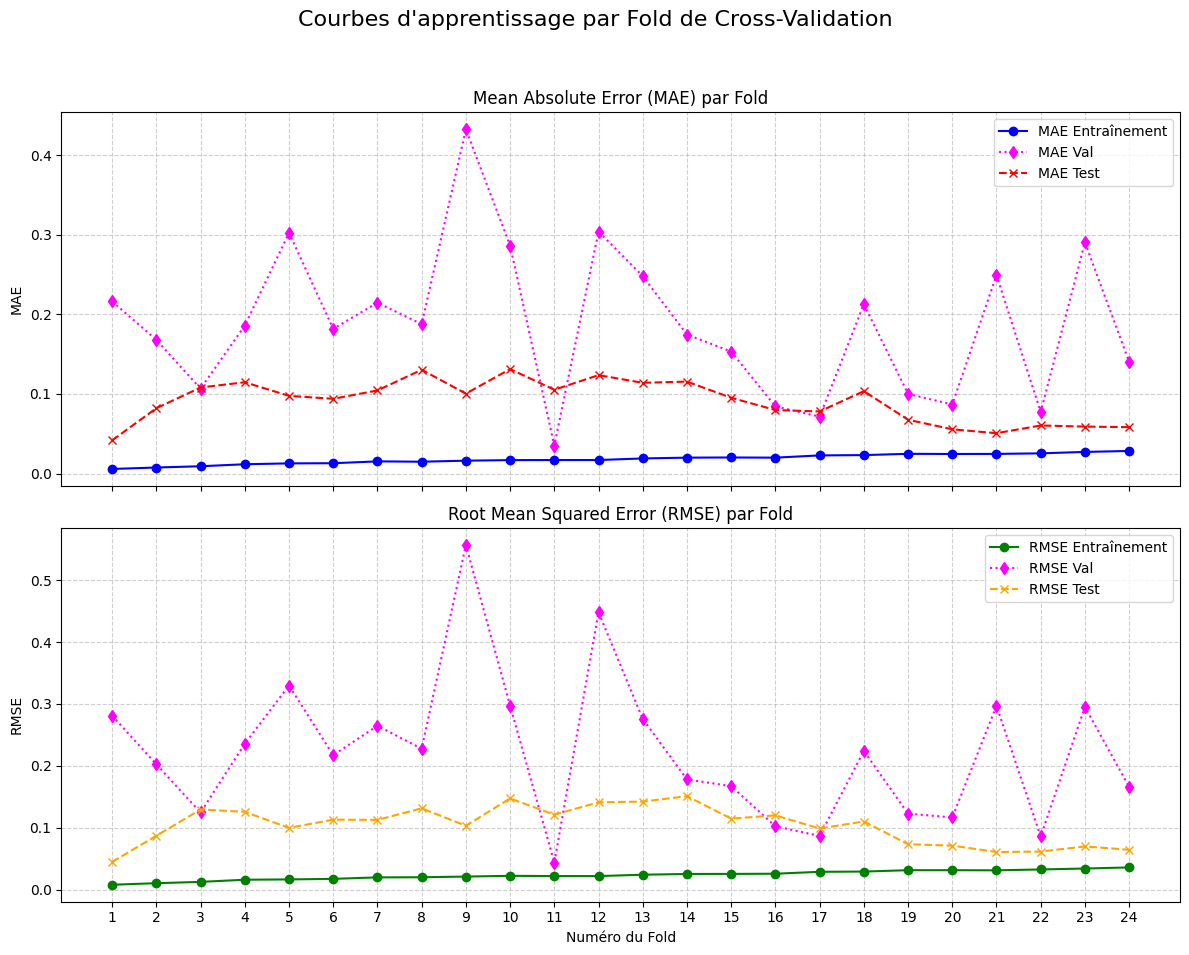

✅ Courbes d'apprentissage affichées.



,lag_1,lag_2,lag_3,lag_12,moyenne_3m,moyenne_6m
date_mesure,,,,,,
1995-01-31,13.468387,13.719667,13.025484,13.856429,13.630964,12.659452
1995-02-28,13.704839,13.468387,13.719667,13.602857,13.677147,13.255821
1995-03-31,13.858214,13.704839,13.468387,12.908065,13.684459,13.544486
1995-04-30,13.490323,13.858214,13.704839,12.849000,13.289623,13.460294
1995-05-31,12.520333,13.490323,13.858214,12.503871,12.737853,13.207500
...,...,...,...,...,...,...
2024-10-31,11.881667,11.699032,12.184516,12.817097,12.294319,12.411568
2024-11-30,13.302258,11.881667,11.699032,14.175333,12.628530,12.388190
2024-12-31,12.701667,13.302258,11.881667,13.583548,12.906470,12.414104


In [ ]:
def plot_learning_curves(cv_metrics: pd.DataFrame):
    """
    Affiche les courbes d'apprentissage (MAE et RMSE) pour les métriques d'entraînement et de test
    obtenues via la cross-validation.
    """

    if not cv_metrics.empty:
        folds = cv_metrics['fold']

        fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
        fig.suptitle('Courbes d\'apprentissage par Fold de Cross-Validation', fontsize=16)

        # Plot MAE
        axes[0].plot(folds, cv_metrics['mae_train'], marker='o', linestyle='-', label='MAE Entraînement', color='blue')
        axes[0].plot(folds, cv_metrics['mae_val'], marker='d', linestyle=':', label='MAE Val', color='magenta')
        axes[0].plot(folds, cv_metrics['mae_test'], marker='x', linestyle='--', label='MAE Test', color='red')
        axes[0].set_ylabel('MAE')
        axes[0].set_title('Mean Absolute Error (MAE) par Fold')
        axes[0].legend()
        axes[0].grid(True, linestyle='--', alpha=0.6)

        # Plot RMSE (qui est la racine carrée du MSE)
        axes[1].plot(folds, cv_metrics['rmse_train'], marker='o', linestyle='-', label='RMSE Entraînement', color='green')
        axes[1].plot(folds, cv_metrics['rmse_val'], marker='d', linestyle=':', label='RMSE Val', color='magenta')
        axes[1].plot(folds, cv_metrics['rmse_test'], marker='x', linestyle='--', label='RMSE Test', color='orange')
        axes[1].set_xlabel('Numéro du Fold')
        axes[1].set_ylabel('RMSE')
        axes[1].set_title('Root Mean Squared Error (RMSE) par Fold')
        axes[1].legend()
        axes[1].grid(True, linestyle='--', alpha=0.6)

        plt.xticks(folds)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
        print("✅ Courbes d'apprentissage affichées.\n")
    else:
        print(Fore.YELLOW + "⚠️ Aucune métrique de CV disponible pour afficher la courbe d'apprentissage." + Style.RESET_ALL)

plot_learning_curves(cv_metrics)
X_train_df


### XGBoost - Slim  - sans les moyenne roulantes

In [ ]:
from hydrosense.interface.main import preprocess_slim
df_slim = preprocess_slim(df)
X_train_df, X_test_df, y_train_df, y_test_df = split_data(df_slim)

# TRAIN / VAL Folding
splits_ml = get_folds(X_train_df.index, n_splits=25, min_train_years=3 , val_months_duration= 3)

# 2. Train — optimize=True pour GridSearchCV
model, history = train(X_train_df, y_train_df, optimize=False)

# Evaluate — même modèle, pas de rechargement
metrics = evaluate(model, X_test_df, y_test_df)

# ou 3 evaluate deeper


Preprocess SLIM done — 389 mois | 7 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 374 mois | Test : 3 mois


⭐️ Use case: train
Model initialized

Training model...
✅ Model trained on 374 rows in 0.35s
   Train MAE  : 0.0762
   Train RMSE : 0.0979
✅ train() done 


⭐️ Use case: evaluate

Evaluating model on 3 rows...
✅ Model evaluated on test set
   MAE  : 0.1789  (erreur moyenne en mètres NGF)
   RMSE : 0.2015 (pénalise les grandes erreurs)
   R²   : -1.1317  (1.0 = parfait)
   Max Error: 0.1675 (erreur maximale absolue)
   RMSSE: nan (erreur par rapport au choix naif)
✅ evaluate() done 



In [ ]:
cv_2, pred_2 = evaluate_deeper(X_train_df, y_train_df, splits_ml, X_test_df, y_test_df)


⭐️ Evaluate_deeper (Cross-Validation)

--- Fold 1/24 ---
Debug: Current fold 1
Debug: len(X_df) = 374
Debug: len(train_idx) = 86
Debug: max(train_idx) = 85
Model initialized

Training model...
✅ Model trained on 86 rows in 0.41s
   Train MAE  : 0.0122
   Train RMSE : 0.0161

Evaluating model on 86 rows...

Evaluating model on 3 rows...

Evaluating model on 3 rows...
  Fold 1 | Train MAE: 0.012 | Val MAE: 0.393 | Test MAE: 0.127
  Fold 1 | Train RMSE: 0.016 | Val RMSE: 0.425 | Test RMSE: 0.176
  Fold 1 | Train RMSSE: 0.0149 | Val RMSSE: 0.3924 | Test RMSSE: 0.1627

--- Fold 2/24 ---
Debug: Current fold 2
Debug: len(X_df) = 374
Debug: len(train_idx) = 98
Debug: max(train_idx) = 97
Model initialized

Training model...
✅ Model trained on 98 rows in 0.74s
   Train MAE  : 0.0157
   Train RMSE : 0.0208

Evaluating model on 98 rows...

Evaluating model on 3 rows...

Evaluating model on 3 rows...
  Fold 2 | Train MAE: 0.016 | Val MAE: 0.102 | Test MAE: 0.122
  Fold 2 | Train RMSE: 0.021 | Val 

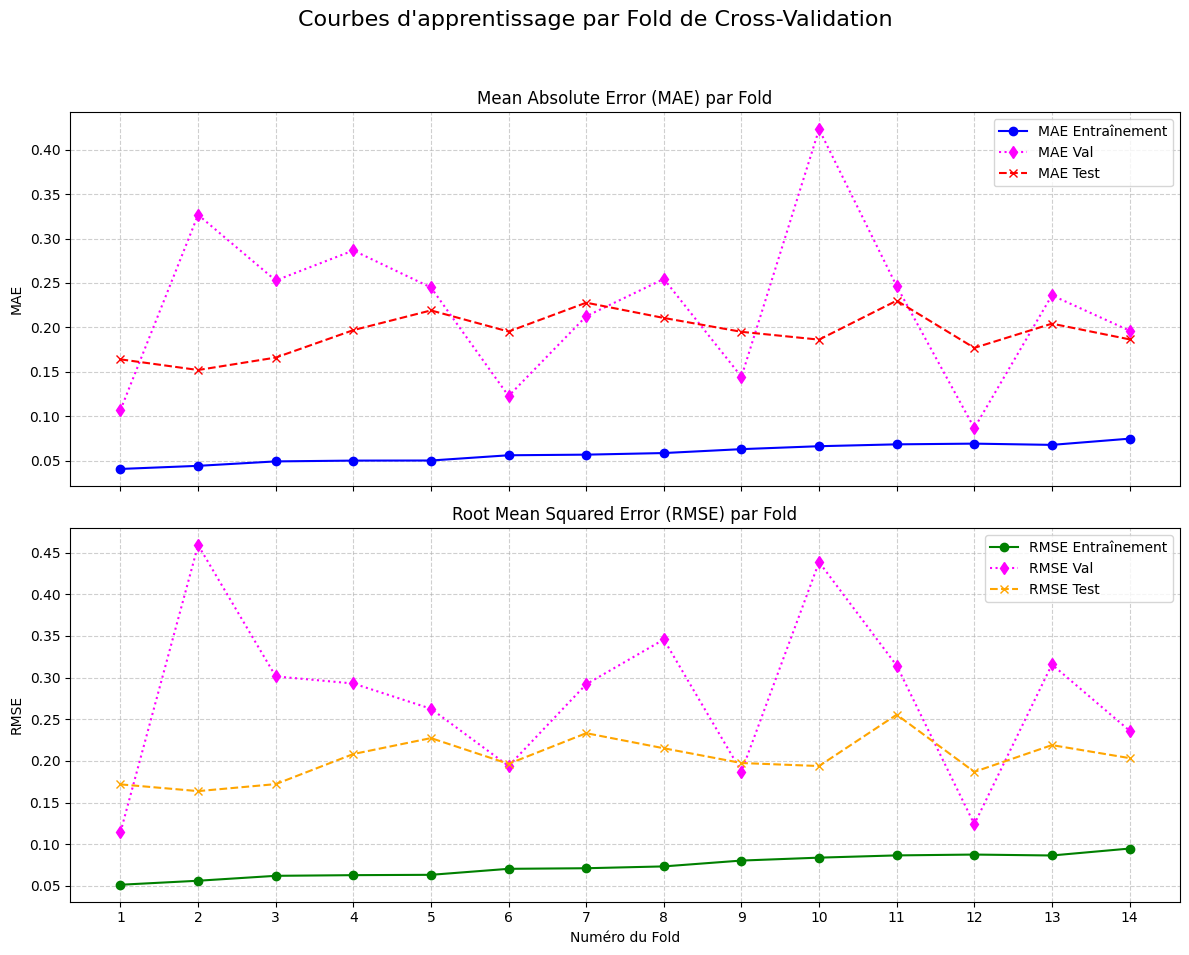

✅ Courbes d'apprentissage affichées.



In [ ]:
plot_learning_curves(cv_2)

Avec la pluie --- 

Petite modif à la volée de load_piezo_bq



In [ ]:
from hydrosense.database.bigquery import load_pem_bq, info_piezo
from hydrosense.preprocess.preprocessor import preprocess_week
from hydrosense.utils.evap import estim_PU


df = load_pem_bq(DATA_CODE_PIEZO)
info = info_piezo(DATA_CODE_PIEZO, raw = False)

altitude_m = float(info['altitude_station'].iloc[0]) if isinstance(info['altitude_station'], pd.Series) else float(info['altitude_station'])
lat_deg = float(info['y'].iloc[0]) if isinstance(info['y'], pd.Series) else float(info['y'])
jours_annee = pd.to_datetime(df[params.DATE_COL]).dt.dayofyear


# Exécution vectorisée (instantanée même sur 1 million de lignes !)
df['PU_synth'] = estim_PU(
    P_mm       = df['RR_synth'],
    T_moy_C    = df['TM_synth'],
    vent_m_s   = df['FFM_synth'],
    lat_deg    = lat_deg,
    altitude_m = altitude_m,
    jour_annee = jours_annee
)

print(df[['RR_synth', 'TM_synth', 'RR_synth','PU_synth']].head())


PEM BSS001QHYH : 11821 lignes chargées
   RR_synth  TM_synth  RR_synth  PU_synth
0       0.0      -1.6       0.0    -0.761
1       0.0      -2.4       0.0    -0.520
2       1.4       1.6       1.4     0.677
3       0.8       3.5       0.8     0.070
4       0.0       5.7       0.0    -0.425


In [ ]:
# verifier que la donnée est bien présente à chaque pas de temps.
df['date_mesure'].diff()[1:].unique()


<TimedeltaArray>
['1 days']
Length: 1, dtype: timedelta64[us]

In [ ]:
from hydrosense.utils.evap import lag_pluie

lags= []
corr_list = []

for bss in params.TARGETS_BSS[:]:

    df = load_pem_bq(bss)
    info = info_piezo(bss, raw = False)
    print(info['code_departement'],info['nom_commune'])


    altitude_m = float(info['altitude_station'].iloc[0]) if isinstance(info['altitude_station'], pd.Series) else float(info['altitude_station'])
    lat_deg = float(info['y'].iloc[0]) if isinstance(info['y'], pd.Series) else float(info['y'])
    jours_annee = pd.to_datetime(df[params.DATE_COL]).dt.dayofyear


    # Exécution vectorisée (instantanée même sur 1 million de lignes !)
    df['PU_synth'] = estim_PU(
        P_mm       = df['RR_synth'],
        T_moy_C    = df['TM_synth'],
        vent_m_s   = df['FFM_synth'],
        lat_deg    = lat_deg,
        altitude_m = altitude_m,
        jour_annee = jours_annee
    )

    lag , corr_pp = lag_pluie(df, toggle_plot= False)
    lags.append(lag)
    corr_list.append(corr_pp)


PEM BSS002DEZW : 10370 lignes chargées
0    82
Name: code_departement, dtype: object 0    Bioule
Name: nom_commune, dtype: object
✅ Le temps de réponse optimal estimé de la nappe est de 99 jours (Corrélation: 0.207).
PEM BSS000ZPHJ : 7464 lignes chargées
0    35
Name: code_departement, dtype: object 0    Bourg-des-Comptes
Name: nom_commune, dtype: object
✅ Le temps de réponse optimal estimé de la nappe est de 93 jours (Corrélation: 0.285).
PEM BSS000ZQXN : 6534 lignes chargées
0    35
Name: code_departement, dtype: object 0    Arbrissel
Name: nom_commune, dtype: object
✅ Le temps de réponse optimal estimé de la nappe est de 88 jours (Corrélation: 0.254).
PEM BSS001PGUQ : 5221 lignes chargées
0    79
Name: code_departement, dtype: object 0    Saint-Gelais
Name: nom_commune, dtype: object
✅ Le temps de réponse optimal estimé de la nappe est de 51 jours (Corrélation: 0.313).
PEM BSS001QTKG : 8852 lignes chargées
0    79
Name: code_departement, dtype: object 0    Sauzé-Vaussais
Name: nom_c

In [ ]:
dict_piezo_lags = {'bss_id': params.TARGETS_BSS, 'lag' : lags, 'correlation': corr_list}

### Preprocess week

Nous avons besoin de changer la fonction de preprocess_week.



In [ ]:
from hydrosense.preprocess.preprocessor import preprocess_week

df_week = preprocess_week(df)
X_train_df, X_test_df, y_train_df, y_test_df = split_data(df_slim)



⭐️ Use case: preprocess
✅ preprocess() done — 1637 semaines | 9 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 362 mois | Test : 3 mois



In [ ]:

# TRAIN / VAL Folding
splits_ml = get_folds(X_train_df.index, n_splits=15, min_train_years=3 , val_months_duration= 3)

# 2. Train — optimize=True pour GridSearchCV
model, history = train(X_train_df, y_train_df, optimize=False)

# 3. Evaluate — même modèle, pas de rechargement
metrics = evaluate(model, X_test_df, y_test_df)

cv_2 = [] # Pour stocker les métriques de chaque fold
all_pred_2 = pd.DataFrame() # Pour stocker toutes les prédictions pour la visualisation

for i, (train_idx, val_idx) in enumerate(splits_ml):

    print(f"\n--- Fold {i+1}/{len(splits_ml)} ---")

    X_train  = X.iloc[train_idx,:]
    y_train = y_target.iloc[train_idx]

    X_val = X.iloc[val_idx,:]
    y_val = y_target.iloc[val_idx]


    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    # options ??


    try:
        rf.fit(X_train, y_train,)
        forecast_rf = pd.Series(rf.predict(X_val), index=y_val.index)
        hindcast_rf = pd.Series(rf.predict(X_train), index=y_train.index)

        score_val = rf.score(X_val, y_val)
        score_train = rf.score(X_train, y_train)

        metrics_train = evaluate_model(rf, X_train, y_train)
        # mae_train = mean_absolute_error(y_train, hindcast_rf)
        # rmse_train = float(np.sqrt(
        #             mean_squared_error(y_train, hindcast_rf)
        #             ))
        # me_train = max_error(y_train, hindcast_rf)

        metrics_val = evaluate_model(rf, X_val, y_val)
        # mae_val = mean_absolute_error(y_val, forecast_rf)
        # rmse_val = float(np.sqrt(
        #             mean_squared_error(y_val, forecast_rf)
        #             ))
        # me_val  = max_error(y_val, forecast_rf)

        # rajouter des metrics. example :NSE - seasonal eror index

        # TODO : construct
        # metrics_test


        # TODO to construct cv results from the metrics_train val and test
        cv_2.append({
                'fold': i + 1,
                # 'train_start': train_data.index.min(), 'train_end': train_data.index.max(),
                'val_start': y_val.index.min(), 'val_end': y_val.index.max(),
                'r2_train' : score_train  , 'mae_train':mae_train, 'rmse_train':rmse_train,'me_train':me_train,
                'r2_val': score_val, 'mae_val':mae_val, 'rmse_val':rmse_val, 'me_val':me_val,
                'test_start': np.nan, 'test_end' : np.nan

            })

        # Stocker les prédictions pour une visualisation ultérieure
        fold_predictions = pd.DataFrame({
                'date': y_val.index,
                'actual': y_val,  'forecast': forecast_rf,
                'fold': i + 1
            })
        all_pred_2 = pd.concat([all_pred_2, fold_predictions])

    except Exception as e:
        print(f"  Erreur lors de l'entraînement ou de la prédiction pour le fold {i+1}: {e}")

#### Learning Curve

### 4.3 grid search pour trouver le meilleur random forest

## 5. XGBoost — Gradient Boosting

**XGBoost** est un algorithme de *gradient boosting* : il construit des arbres de décision
en séquence, chaque arbre corrigeant les erreurs du précédent.

Il surpasse souvent le Random Forest sur les séries temporelles car il est plus sensible
aux **relations non-linéaires** et aux **interactions entre features**.

La grille de paramètres testés :
- `n_estimators` : nombre d'arbres
- `learning_rate` : vitesse d'apprentissage (trop élevé = overfitting)
- `max_depth` : profondeur max de chaque arbre
- `subsample` / `colsample_bytree` : régularisation par sous-échantillonnage

In [ ]:
# 1. Préparation des colonnes (Lag)
df_w = pd.DataFrame(y_week)
df_w['semaine'] = df_w.index.isocalendar().week
df_w['lag_1'] = df_w['niveau_nappe_eau'].shift(1)
df_w['lag_2'] = df_w['niveau_nappe_eau'].shift(2)
df_w['lag_3'] = df_w['niveau_nappe_eau'].shift(3)
df_w['lag_4'] = df_w['niveau_nappe_eau'].shift(4)
df_w['lag_52'] = df_w['niveau_nappe_eau'].shift(52)


In [ ]:
# Moyenne du niveau de la nappe sur les 3 derniers mois (tendance récente)
df_w['moyenne_3w'] = df_w['niveau_nappe_eau'].shift(1).rolling(window=3).mean()

# Moyenne du niveau sur les 6 derniers mois (tendance moyen terme)
df_w['moyenne_6w'] = df_w['niveau_nappe_eau'].shift(1).rolling(window=6).mean()

# IMPORTANT : Applique le .dropna() APRÈS avoir créé ces nouvelles variables
df_w = df_w.dropna()

X = df_w[['semaine', 'lag_1', 'lag_2', 'lag_3','lag_4', 'lag_52', 'moyenne_3w', 'moyenne_6w']]

y_target = df_w['niveau_nappe_eau']

# Split Train / Test
X_train, X_test = X.loc[:'2026-02-28'], X.loc['2026-03-01':'2026-05-31']
y_train, y_test = y_target.loc[:'2026-02-28'], y_target.loc['2026-03-01':'2026-05-31']

In [ ]:
X_train.head()

,semaine,lag_1,lag_2,lag_3,lag_4,lag_52,moyenne_3w,moyenne_6w
date_mesure,,,,,,,,
1995-02-05,5,14.321429,13.450000,13.261429,13.645714,13.690000,13.677619,13.619762
1995-02-12,6,13.988571,14.321429,13.450000,13.261429,13.732857,13.920000,13.701429
1995-02-19,7,13.705714,13.988571,14.321429,13.450000,13.657143,14.005238,13.728810
1995-02-26,8,13.908571,13.705714,13.988571,14.321429,13.384286,13.867619,13.772619
1995-03-05,9,13.895714,13.908571,13.705714,13.988571,13.217143,13.836667,13.878333


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import pandas as pd

# 1. On définit la grille des paramètres à tester
param_grid_xgb = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.8, 1.0]
}


# 2. Instanciation du modèle de base
xgb_base = XGBRegressor(random_state=42)

# 3. Configuration de la recherche automatique (avec 3 découpages de validation)
grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# 4. Entraînement sur tes données (X_train et y_train avec les Lags)
grid_search_xgb.fit(X_train, y_train)

# 5. Affichage des meilleurs réglages trouvés
print("Meilleurs paramètres XGBoost :", grid_search_xgb.best_params_)


Meilleurs paramètres XGBoost : {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.9}


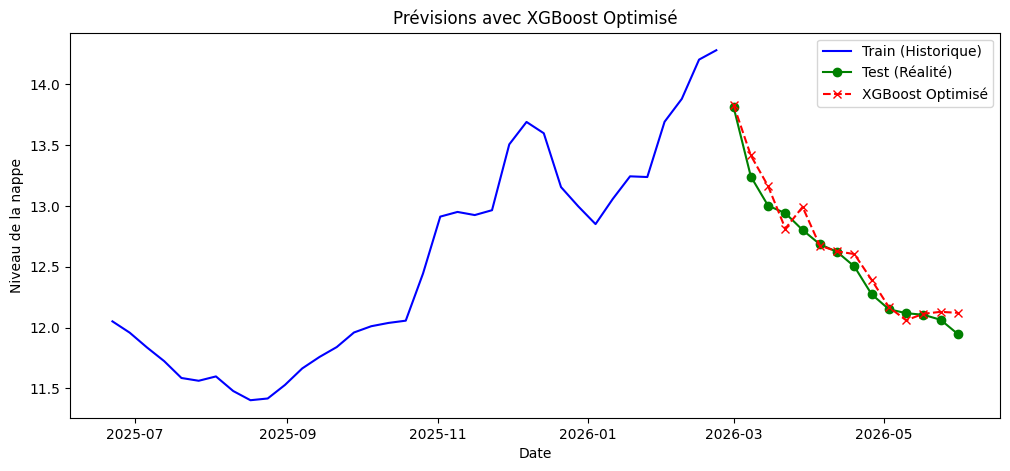

In [ ]:
# 1. Récupération du meilleur modèle
best_xgb = grid_search_xgb.best_estimator_

# 2. Prédiction sur l'année de test
forecast_xgb_opt = pd.Series(best_xgb.predict(X_test), index=y_test.index)

# 3. Graphique de comparaison
plt.figure(figsize=(12, 5))
plt.plot(y_train.tail(36), label='Train (Historique)', color='blue')
plt.plot(y_test, label='Test (Réalité)', color='green', marker='o')
plt.plot(forecast_xgb_opt, label='XGBoost Optimisé', color='red', linestyle='--', marker='x')

plt.title("Prévisions avec XGBoost Optimisé")
plt.xlabel("Date")
plt.ylabel("Niveau de la nappe")
plt.legend()
plt.show()